In [1]:
##import
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import GlobalAveragePooling2D,Dense,BatchNormalization,Dropout,Flatten,Conv2D,MaxPooling2D
from tensorflow.keras.optimizers import Adam
import numpy as np
import random
import matplotlib.pyplot as plt
%matplotlib inline

2026-07-11 00:52:25.536236: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-11 00:52:25.589405: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-11 00:52:26.637047: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [29]:
import tensorflow as tf

## Loading the data

In [15]:
im_shape = (250,250)

TRAINING_DIR = "DATA/train/"
TEST_DIR = "DATA/test/"

In [6]:
seed = 10

In [7]:
BATCH_SIZE = 16

In [8]:
## using keras image gen

data_generator = ImageDataGenerator(rescale=1./255,validation_split=0.2)
val_data_generator = ImageDataGenerator(rescale=1./255,validation_split=0.2)

In [10]:
## Generating for train part

train_generator = data_generator.flow_from_directory(TRAINING_DIR,target_size=im_shape,shuffle=True,seed=seed,class_mode="categorical",batch_size=BATCH_SIZE,subset="training")
validation_generator= val_data_generator.flow_from_directory(TRAINING_DIR,target_size=im_shape,shuffle=False,seed=seed,class_mode="categorical",batch_size=BATCH_SIZE,subset="validation")



In [13]:
## gesting the test dataset

In [16]:
test_generator = ImageDataGenerator(rescale=1./255)
test_generator = test_generator.flow_from_directory(TEST_DIR,target_size=im_shape,shuffle=False,seed=seed,class_mode="categorical",batch_size=BATCH_SIZE)

Found 30 images belonging to 6 classes.


### NB Train samples

In [17]:
nb_train_samples = train_generator.samples
nb_validation_samples = validation_generator.samples
nb_test_samples = test_generator.samples

In [18]:
classes = list(train_generator.class_indices.keys())
print("Classes:"+str(classes))
num_classes = len(classes)

Classes:['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


## Creating a Simple Model

In [20]:
model = Sequential()
model.add(Conv2D(20,kernel_size=(3,3),activation="relu",input_shape=(im_shape[0],im_shape[1],3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(40,kernel_size=(3,3),activation="relu"))
model.add(Flatten())
model.add(Dense(100,activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(num_classes,activation="softmax"))
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 248, 248, 20)      560       
                                                                 
 max_pooling2d (MaxPooling2  (None, 124, 124, 20)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 122, 122, 40)      7240      
                                                                 
 flatten (Flatten)           (None, 595360)            0         
                                                                 
 dense (Dense)               (None, 100)               59536100  
                                                                 
 dropout (Dropout)           (None, 100)               0         
                                                        

2026-07-11 01:11:43.026278: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-11 01:11:43.053550: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [21]:
## Training the moel

In [46]:
epochs = 80 

callbacks_list = [
    keras.callbacks.ModelCheckpoint(
        filepath="model.h5",
        monitor="loss",
        save_best_only=True,
        verbose=1),
    keras.callbacks.EarlyStopping(monitor="loss",patience=30,verbose=1)
    
]

In [47]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [48]:
## Training
history = model.fit(
    train_generator,
    steps_per_epoch = nb_train_samples // BATCH_SIZE,
    epochs = epochs,
    callbacks= callbacks_list,
    validation_data = validation_generator,
    verbose = 1,
    validation_steps = nb_validation_samples // BATCH_SIZE)


Epoch 1/80
1/1 [==============================] - ETA: 0s - loss: 0.0088 - accuracy: 1.0000
Epoch 1: loss improved from inf to 0.00883, saving model to model.h5
1/1 [==============================] - 1s 1s/step - loss: 0.0088 - accuracy: 1.0000
Epoch 2/80
1/1 [==============================] - ETA: 0s - loss: 0.0136 - accuracy: 1.0000
Epoch 2: loss did not improve from 0.00883
1/1 [==============================] - 0s 246ms/step - loss: 0.0136 - accuracy: 1.0000
Epoch 3/80
1/1 [==============================] - ETA: 0s - loss: 0.0349 - accuracy: 1.0000
Epoch 3: loss did not improve from 0.00883
1/1 [==============================] - 0s 250ms/step - loss: 0.0349 - accuracy: 1.0000
Epoch 4/80
1/1 [==============================] - ETA: 0s - loss: 2.0862e-07 - accuracy: 1.0000
Epoch 4: loss improved from 0.00883 to 0.00000, saving model to model.h5
1/1 [==============================] - 1s 730ms/step - loss: 2.0862e-07 - accuracy: 1.0000
Epoch 5/80
1/1 [==============================] - E

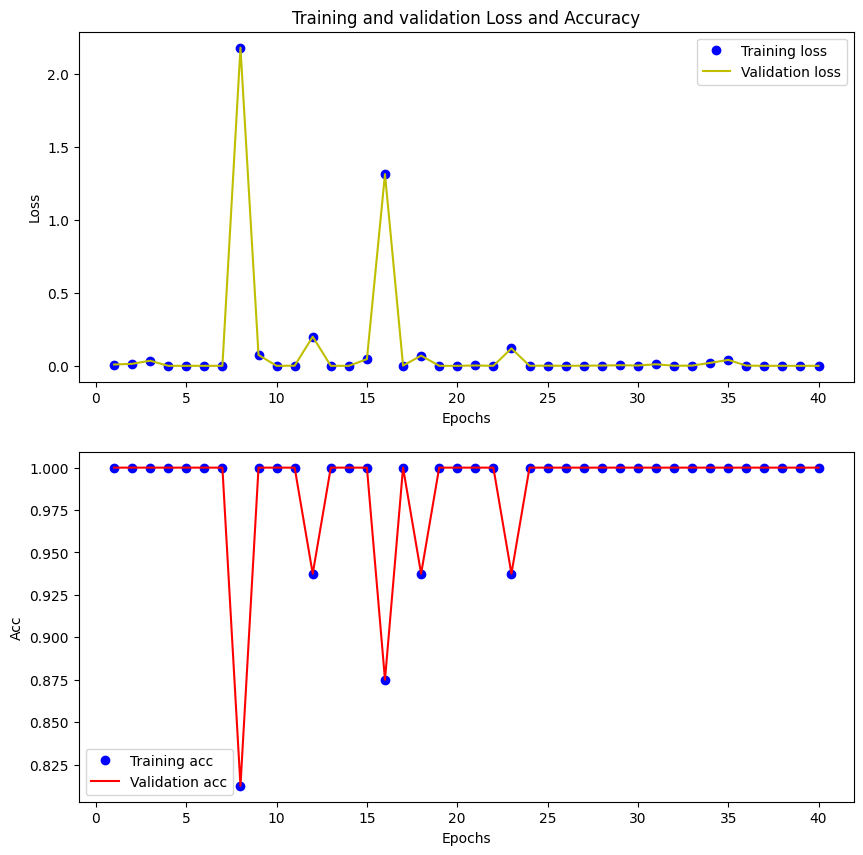

In [49]:
# Training curves
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['loss']

epochs_x = range(1, len(loss_values) + 1)
plt.figure(figsize=(10,10))
plt.subplot(2,1,1)
plt.plot(epochs_x, loss_values, 'bo', label='Training loss')
plt.plot(epochs_x, val_loss_values, 'y', label='Validation loss')
plt.title('Training and validation Loss and Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(2,1,2)
acc_values = history_dict['accuracy']
val_acc_values = history_dict['accuracy']
plt.plot(epochs_x, acc_values, 'bo', label='Training acc')
plt.plot(epochs_x, val_acc_values, 'r', label='Validation acc')
#plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Acc')
plt.legend()
plt.show()

## THe computer was on CPU 